# Finetuning Custom ResNet

In [ ]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb

In [34]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
import torchmetrics
import librosa
from tqdm import tqdm
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.lib.display import Audio as AudioDisplay

## Configuration

In [35]:
SEED = 1337
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PETRAINED_MODEL = "models/foundation_model.pt"
LEARNING_RATE = 1e-4  # Normal LR
BATCH_SIZE = 32
EPOCHS = 3
NUM_WORKERS = 20
WEIGHT_DECAY = 1.00E-03
MODEL_SAVE_PATH = "models/finetuned_model.pt"

# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")

Using device: cuda
Number of workers: 20


## Load finetuning dataset

In [36]:
dataset = load_dataset("Hibou-Foundation/ds_finetuning_dataset_1")
dataset = dataset.with_format("torch", columns=["audio", "label"])
# Split in train test val sets
dataset = dataset["train"].train_test_split(test_size=0.2, seed=SEED)
val_test_ds = dataset["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": dataset["train"],
    "val": val_test_ds["train"],
    "test": val_test_ds["test"],
})

In [37]:
print(dataset["train"][0]["audio"].shape, dataset["train"][0]["label"])

torch.Size([8000]) tensor(1)


In [53]:
def apply_random_gain(audio, min_db=-20, max_db=10):
    """Apply random gain to audio to decorrelate volume from class.
    This prevents the model from learning that 'loud = drone'."""
    gain_db = np.random.uniform(min_db, max_db)
    gain_linear = 10 ** (gain_db / 20)
    return audio * gain_linear


def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_train(batch):
    """Collate function for training with volume augmentation."""
    inputs = []
    labels = []

    for item in batch:
        waveforme = np.asarray(item["audio"])
        waveforme = apply_random_gain(waveforme, min_db=-20, max_db=10)
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    return inputs, labels


def collate_fn_eval(batch):
    """Collate function for validation/test without augmentation."""
    inputs = []
    labels = []

    for item in batch:
        waveforme = np.asarray(item["audio"])
        # No augmentation for evaluation
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    return inputs, labels


train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn_train, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn_eval, pin_memory=True)
test_loader = DataLoader(dataset["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn_eval, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")


Created DataLoaders with Batch Size: 32
Sample batch shape - X: torch.Size([32, 1, 128, 32]), Y: torch.Size([32, 1])


## Model Definition

In [54]:
from model import AudioResNet

model = AudioResNet().to(DEVICE)
model.load_state_dict(torch.load(PETRAINED_MODEL, map_location=DEVICE))
print(f"Loaded pretrained weights from {PETRAINED_MODEL}")

Loaded pretrained weights from models/foundation_model.pt


## Finetuning Setup

In [55]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)

In [56]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")


Starting training...


Epoch 1/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.02batch/s, loss=0.00182]



Epoch 1/3 | Train Loss: 0.5085 | Train Acc: 0.9225 | Val Loss: 0.1294 | Val Acc: 0.9662
Saved new best model to models/finetuned_model.pt (Val Acc: 0.9662)


Epoch 2/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.31batch/s, loss=0.00166]



Epoch 2/3 | Train Loss: 0.0530 | Train Acc: 0.9826 | Val Loss: 0.1114 | Val Acc: 0.9702
Saved new best model to models/finetuned_model.pt (Val Acc: 0.9702)


Epoch 3/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.20batch/s, loss=0.00396]


Epoch 3/3 | Train Loss: 0.0231 | Train Acc: 0.9916 | Val Loss: 0.1015 | Val Acc: 0.9702

Training complete.


In [42]:
# Plot history...

In [57]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
# LOAD_MODEL_PATH = "models/foundation_model.pt"
print(f"Loading best model from {LOAD_MODEL_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(LOAD_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")

Loading best model from models/finetuned_model.pt...
Loaded best model and set to eval mode.


In [58]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")

Testing: 100%|██████████| 16/16 [00:03<00:00,  4.02it/s]


Test evaluation complete.



Test Accuracy: 98.61%

Classification Report:
              precision    recall  f1-score   support

       other      0.970     0.977     0.974       132
       drone      0.992     0.989     0.991       372

    accuracy                          0.986       504
   macro avg      0.981     0.983     0.982       504
weighted avg      0.986     0.986     0.986       504



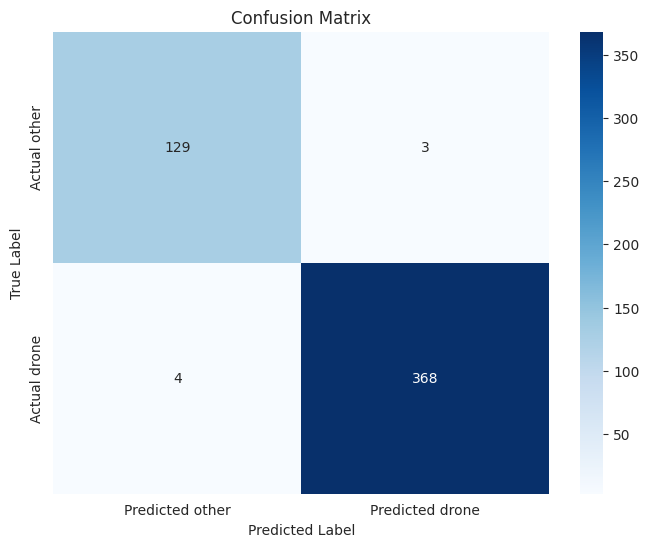


Results DataFrame head:
   true_label  pred_label    confidence
0         1.0         1.0  1.000000e+00
1         0.0         0.0  2.200237e-03
2         0.0         0.0  8.650663e-07
3         0.0         0.0  1.635861e-05
4         0.0         0.0  2.400040e-04


In [59]:

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
target_names = dataset["train"].features["label"].names

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())

In [61]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")

In [62]:
import librosa
def convert_to_mel_spectrogram_inference(data):
    """Mel spectrogram conversion for inference - must match training preprocessing."""
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
    # Convert to log scale (dB) with fixed reference (must match training!)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram_inference(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels

In [63]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders

{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b1450>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b2450>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b1a50>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b0750>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b2650>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b0550>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b1750>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b1c50>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7f26b95b2050>}

In [64]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)

Testing parabole7: 100%|██████████| 7953/7953 [00:28<00:00, 280.70it/s]


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])

drone_test {'accuracy': 0.9843225083986562, 'precision': 0.9868421052631579, 'recall': 0.9765625, 'f1': 0.981675392670157, 'auc': 0.9833696586444007, 'confusion_matrix': array([[504,   5],
       [  9, 375]])}
drone_test_2 {'accuracy': 0.9975044563279858, 'precision': 1.0, 'recall': 0.9975035663338089, 'f1': 0.9987502231744332, 'auc': 0.9987517831669044, 'confusion_matrix': array([[   1,    0],
       [   7, 2797]])}
parabole1 {'accuracy': 0.991869918699187, 'precision': 0.9873417721518988, 'recall': 1.0, 'f1': 0.9936305732484076, 'auc': 0.9888888888888888, 'confusion_matrix': array([[44,  1],
       [ 0, 78]])}
parabole2 {'accuracy': 0.9882352941176471, 'precision': 0.9833333333333333, 'recall': 1.0, 'f1': 0.9915966386554622, 'auc': 0.9807692307692308, 'confusion_matrix': array([[25,  1],
       [ 0, 59]])}
parabole3 {'accuracy': 0.9963636363636363, 'precision': 1.0, 'recall': 0.9955555555555555, 'f1': 0.9977728285077951, 'auc': 0.9977777777777778, 'confusion_matrix': array([[ 50,   0

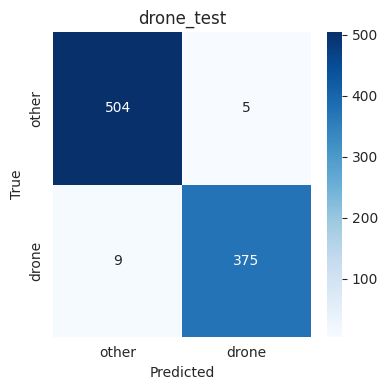

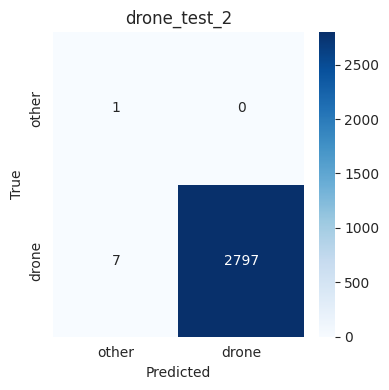

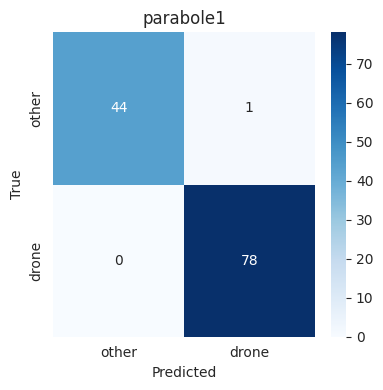

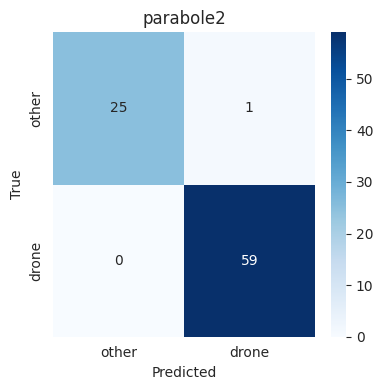

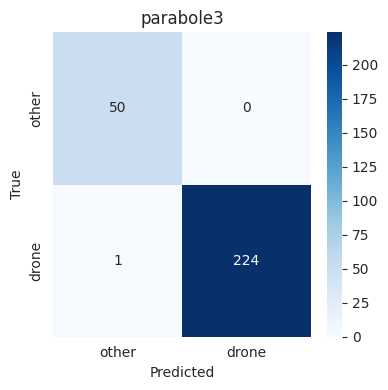

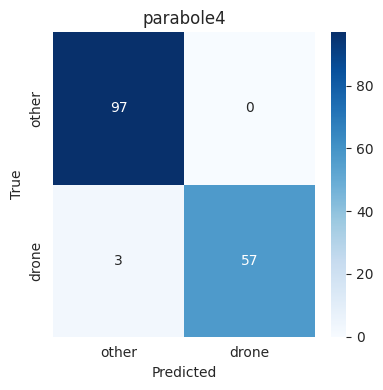

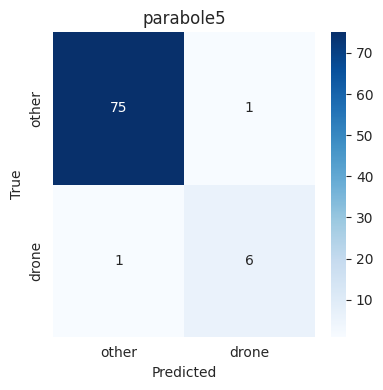

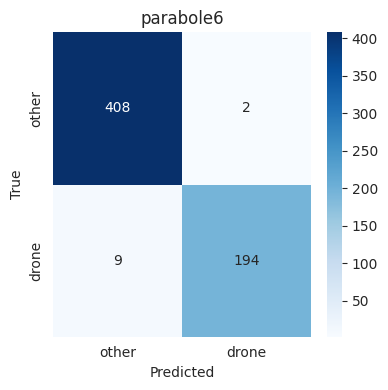

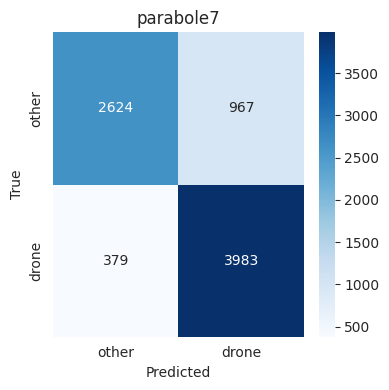

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)

In [69]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram_inference(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("/home/pierre/Documents/Projects/PST4/AI/data/raw/test/02-02-2026/other")

0 is 'other', 1 is 'drone'
Using threshold: 0.5


=== Results (threshold=0.5) ===
Total files: 760
Predicted as drone: 33 (4.34%)
Predicted as other: 727 (95.66%)


[{'file': 'aigu_pierre0_chunk1.wav',
  'predicted_label': 0,
  'confidence': 3.102048867731355e-05},
 {'file': 'aigu_pierre0_chunk10.wav',
  'predicted_label': 0,
  'confidence': 2.4450116598018212e-06},
 {'file': 'aigu_pierre0_chunk100.wav',
  'predicted_label': 0,
  'confidence': 0.004664272535592318},
 {'file': 'aigu_pierre0_chunk101.wav',
  'predicted_label': 0,
  'confidence': 0.06648131459951401},
 {'file': 'aigu_pierre0_chunk102.wav',
  'predicted_label': 0,
  'confidence': 0.0001111064339056611},
 {'file': 'aigu_pierre0_chunk103.wav',
  'predicted_label': 0,
  'confidence': 4.2460587934556315e-08},
 {'file': 'aigu_pierre0_chunk104.wav',
  'predicted_label': 0,
  'confidence': 3.8386446021831944e-07},
 {'file': 'aigu_pierre0_chunk105.wav',
  'predicted_label': 0,
  'confidence': 2.1008359851748537e-07},
 {'file': 'aigu_pierre0_chunk106.wav',
  'predicted_label': 0,
  'confidence': 2.4605060389149003e-06},
 {'file': 'aigu_pierre0_chunk107.wav',
  'predicted_label': 0,
  'confiden